In [21]:
import duckdb
import pandas as pd
import seaborn as sns

%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [22]:
%%sql
CREATE TABLE hpi AS FROM '../data/raw/UK-*.csv';

Running query in 'duckdb'

Count
149085


In [23]:
conn.sql("DESCRIBE hpi").show(max_rows=100)

┌────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │ column_type │  null   │   key   │ default │  extra  │
│        varchar         │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Date                   │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ RegionName             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AreaCode               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AveragePrice           │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Index                  │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ IndexSA                │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ 1m%Change              │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ 12m%Change             │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ AveragePriceSA         │ V

In [24]:
%%sql 
SELECT MIN(Date), MAX(Date) FROM hpi

Running query in 'duckdb'

min(Date),max(Date)
1968-04-01,2025-12-01


In [25]:
conn.sql("""
        SELECT DISTINCT RegionName, AreaCode 
        FROM hpi
        ORDER BY RegionName    
        """).show(max_rows=500)

┌─────────────────────────────────────┬───────────┐
│             RegionName              │ AreaCode  │
│               varchar               │  varchar  │
├─────────────────────────────────────┼───────────┤
│ Aberdeenshire                       │ S12000034 │
│ Adur                                │ E07000223 │
│ Amber Valley                        │ E07000032 │
│ Angus                               │ S12000041 │
│ Antrim and Newtownabbey             │ N09000001 │
│ Ards and North Down                 │ N09000011 │
│ Argyll and Bute                     │ S12000035 │
│ Armagh City Banbridge and Craigavon │ N09000002 │
│ Arun                                │ E07000224 │
│ Ashfield                            │ E07000170 │
│ Ashford                             │ E07000105 │
│ Babergh                             │ E07000200 │
│ Barking and Dagenham                │ E09000002 │
│ Barnet                              │ E09000003 │
│ Barnsley                            │ E08000038 │
│ Basildon  

In [26]:
avg_prices_per_date = conn.sql(""" 
         SELECT 
            Date,
            AveragePrice,
            DetachedPrice,
            SemiDetachedPrice,
            TerracedPrice,
            FlatPrice
         FROM hpi
         WHERE RegionName = 'United Kingdom'
         """)
avg_prices_per_date

┌────────────┬──────────────┬───────────────┬───────────────────┬───────────────┬───────────┐
│    Date    │ AveragePrice │ DetachedPrice │ SemiDetachedPrice │ TerracedPrice │ FlatPrice │
│    date    │    int64     │     int64     │       int64       │     int64     │   int64   │
├────────────┼──────────────┼───────────────┼───────────────────┼───────────────┼───────────┤
│ 1968-04-01 │         3311 │          NULL │              NULL │          NULL │      NULL │
│ 1968-05-01 │         3311 │          NULL │              NULL │          NULL │      NULL │
│ 1968-06-01 │         3311 │          NULL │              NULL │          NULL │      NULL │
│ 1968-07-01 │         3424 │          NULL │              NULL │          NULL │      NULL │
│ 1968-08-01 │         3424 │          NULL │              NULL │          NULL │      NULL │
│ 1968-09-01 │         3424 │          NULL │              NULL │          NULL │      NULL │
│ 1968-10-01 │         3405 │          NULL │              N

Text(0.5, 1.0, 'Average House Price (1968-2025)')

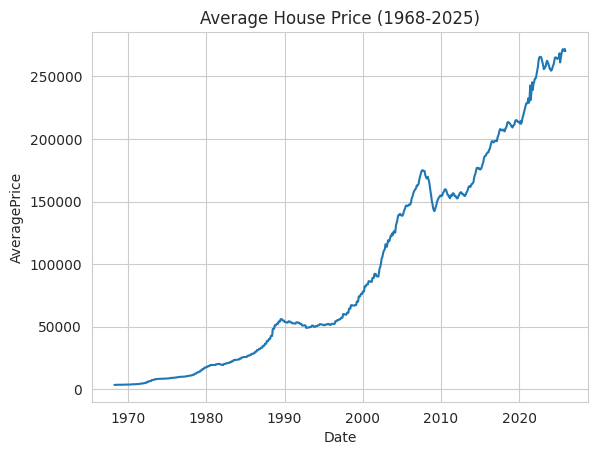

In [37]:
## Average house prices since 1968
sns.set_style("whitegrid")
sns.lineplot(data=avg_prices_per_date.to_df(), x="Date", y="AveragePrice").set_title("Average House Price (1968-2025)")

Text(0.5, 1.0, 'Average Price per House Type (2005-2025)')

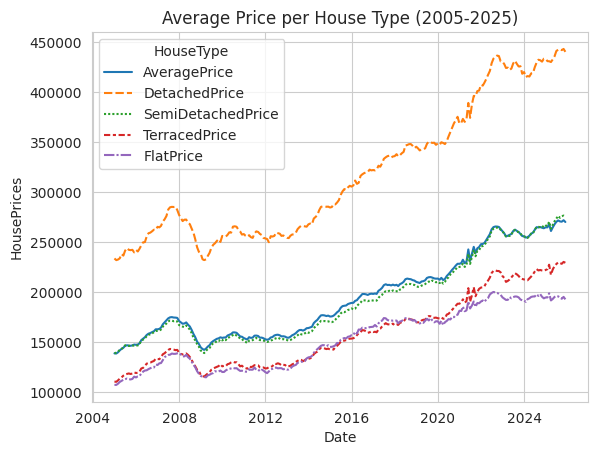

In [38]:
## Average house prices per house type since 2005
avg_prices_per_date_non_null = conn.sql(""" 
         FROM avg_prices_per_date
         WHERE DetachedPrice IS NOT NULL                               
         """).to_df()

avg_prices_per_date_non_null = pd.melt(avg_prices_per_date_non_null, id_vars='Date', 
                                       value_vars=["AveragePrice","DetachedPrice", "SemiDetachedPrice", "TerracedPrice", "FlatPrice"], 
                                       value_name='HousePrices', 
                                       var_name='HouseType')

sns.lineplot(data=avg_prices_per_date_non_null, x="Date", y="HousePrices",hue="HouseType", style="HouseType").set_title("Average Price per House Type (2005-2025)")